In [38]:
# OPTIONAL: Load the "autoreload" extension so that code can change
%load_ext autoreload
# Always reload modules so that as you change code in src, it gets loaded
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [39]:
import numpy as np
from pathlib import Path
import pandas as pd
from tqdm import tqdm

from matplotlib import pyplot as plt


# import scienceplots
import src.utils.setup_figures as figures

In [40]:

# style = ["dark_background"]
# plt.style.use(style)
figures.setup()
colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

### Utils

In [118]:
def timestamp_to_ms(pd_series):
    # Convert timestamp to datetime, allowing automatic parsing
    series = pd.to_datetime(pd_series, errors="coerce")

    # Convert to milliseconds
    ms = series.dt.hour * 3600 * 1000 + series.dt.minute * 60 * 1000 + series.dt.second * 1000 + series.dt.microsecond // 1000

    # Replace NaN values with 0 before converting to integer
    ms = ms.astype("Int64")

    return ms

### Compile data

In [42]:
def get_sessions_between_dates(mouse_id, experiment_type, start_date, end_date=None):
    if end_date is None:
        end_date = pd.to_datetime("today")  # Use today's date as default

    # Convert start_date and end_date to datetime (allowing flexible parsing)
    start_date = pd.to_datetime(start_date, dayfirst=False, yearfirst=True, errors="coerce")
    end_date = pd.to_datetime(end_date, dayfirst=False, yearfirst=True, errors="coerce")

    assert start_date <= end_date, "start_date should be less than or equal to end_date"

    # Read CSV
    summary_data = pd.read_csv(rf"Y:\{mouse_id}\data\random_dot_motion\{experiment_type}\{mouse_id}_summary.csv")

    # Convert the 'date' column to datetime format with error handling
    summary_data["date"] = pd.to_datetime(summary_data["date"], dayfirst=False, yearfirst=True, errors="coerce")

    # Filter data based on date range
    temp_pd = summary_data[(summary_data["date"] >= start_date) & (summary_data["date"] <= end_date)].copy()

    return temp_pd["session"].values  # Ensure accessing the correct column

In [104]:
aggregate_data = pd.DataFrame()
aggregate_licks = pd.DataFrame()

mice = ["DBM22", "DBM23", "DBM24", "DBM26", "DBM27", "DBM28", "DBM29", "DBM30", "DBM32", "DBM33", "DBM34", "DBM38", "DBM40"]
experiment_type = "rt_directional_training"
start_date = "Jan-27-2025"
end_date = None

for mouse_id in mice:

    sessions = get_sessions_between_dates(mouse_id=mouse_id, experiment_type=experiment_type, start_date=start_date, end_date=end_date)

    for session_id in sessions:

        session_data = pd.read_csv(rf"Y:\{mouse_id}\data\random_dot_motion\{experiment_type}\{session_id}\{mouse_id}_trial.csv", index_col=0)
        session_data["mouse_id"] = mouse_id
        session_data["session_id"] = session_id
        # # remove first and last trial
        # session_data = session_data.iloc[1:-1]

        lick_data = pd.read_csv(rf"Y:\{mouse_id}\data\random_dot_motion\{experiment_type}\{session_id}\{mouse_id}_lick.csv", header=None)
        lick_data.columns = ["hw_time", "session_time", "trial_time", "lick_type", "lick_dur"]
        lick_data["mouse_id"] = mouse_id
        lick_data["session_id"] = session_id
        lick_data["session_time"] *= 1000
        lick_data["trial_time"] *= 1000
        lick_data["lick_dur"] *= 1000

        aggregate_data = pd.concat([aggregate_data, session_data])
        aggregate_licks = pd.concat([aggregate_licks, lick_data])

In [111]:
# for rows where outcome is nan, set stimulus_onset, response_onset, reinforcement_onset to nan
aggregate_data.loc[aggregate_data["outcome"].isna(), ["stimulus_onset", "response_onset", "reinforcement_onset"]] = np.nan

In [119]:
events = ["fixation_onset", "stimulus_onset", "response_onset", "reinforcement_onset", "intertrial_onset"]

for event in events:
    aggregate_data[event + "_ms"] = timestamp_to_ms(aggregate_data[event])

# aggregate_data["fixation_onset_ms"] = aggregate_data["stimulus_onset_ms"] - (aggregate_data["fixation_duration"] * 1e3)
aggregate_data["next_fixation_onset_ms"] = aggregate_data["fixation_onset_ms"].shift(-1)

<ipython-input-118-d6387255cc1d>:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  series = pd.to_datetime(pd_series, errors="coerce")
<ipython-input-118-d6387255cc1d>:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  series = pd.to_datetime(pd_series, errors="coerce")
<ipython-input-118-d6387255cc1d>:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  series = pd.to_datetime(pd_series, errors="coerce")
<ipython-input-118-d6387255cc1d>:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent 

In [121]:
aggregate_data["next_fixation_onset_ms"] = (
    aggregate_data["fixation_onset_ms"]
    .shift(-1)  # Shift values up by one row
    .where(aggregate_data["stimulus_onset_ms"].shift(-1).notna())  # Only take values if next row has non-NaN stimulus_onset_ms
    .bfill()  # Fill remaining NaN values by propagating next available non-NaN value
)

In [122]:
time_data = aggregate_data[
    [
        "fixation_onset_ms",
        "stimulus_onset_ms",
        "response_onset_ms",
        "reinforcement_onset_ms",
        "intertrial_onset_ms",
        "next_fixation_onset_ms",
    ]
]
time_data = time_data.subtract(aggregate_data["fixation_onset_ms"], axis=0)
time_data = pd.concat([aggregate_data[["mouse_id", "session_id"]], time_data], axis=1)

### Fixation Onset aligned

In [124]:
# get uique combinations of mouse_id and session_id to loop over
unique_sessions = aggregate_data[["mouse_id", "session_id"]].drop_duplicates()

# Initialize a larger array to store all trials with global indexing
max_licks_per_trial = 500  # Adjust based on the maximum licks per trial
all_trials_parsed_licks = np.empty([len(aggregate_data), max_licks_per_trial]) * np.NaN

global_trial_idx = 0  # Initialize a global trial index

for _, (mouse_id, session_id) in unique_sessions.iterrows():
    # Get the data for the current session
    trials = aggregate_data[(aggregate_data["mouse_id"] == mouse_id) & (aggregate_data["session_id"] == session_id)]
    licks = aggregate_licks[(aggregate_licks["mouse_id"] == mouse_id) & (aggregate_licks["session_id"] == session_id)]

    start = trials["fixation_onset_ms"]
    end = trials["next_fixation_onset_ms"]

    for idx_trial in range(len(trials)):
        # Get the licks for the current trial
        parsed_trial_licks = licks['session_time'][(licks["session_time"] > start.iloc[idx_trial]) & (licks["session_time"] < end.iloc[idx_trial])].values.astype(int)

        all_trials_parsed_licks[global_trial_idx, :len(parsed_trial_licks)] = parsed_trial_licks - start.iloc[idx_trial]

        global_trial_idx += 1

In [125]:
time_data = aggregate_data[
    [
        "fixation_onset_ms",
        "stimulus_onset_ms",
        "response_onset_ms",
        "reinforcement_onset_ms",
        "intertrial_onset_ms",
        "next_fixation_onset_ms",
    ]
]
time_data = time_data.subtract(aggregate_data["fixation_onset_ms"], axis=0)
time_data = pd.concat([aggregate_data[["mouse_id", "session_id"]], time_data], axis=1)

#### removing first and last trial from session.

In [ ]:
np.where(time_data["next_fixation_onset_ms"].fillna(0) < 0)[0]

array([  150,   151,   152,   153,   154,   155,   156,   157,   158,
         159,   160,   161,   162,   163,   164,   165,   166,   167,
         168,   169,   170,   171,   172,   173,   174,   175,   176,
         177,   178,   179,   180,   181,   182,   183,   184,   185,
         186,   187,   188,   189,   190,   191,   192,   193,   194,
         195,   196,   197,   198,   199,   200,   201,   202,   203,
         204,   205,   206,   207,   208,   209,   210,   211,   212,
         213,   214,   215,   216,   217,   218,   219,   220,   221,
         222,   223,   224,   225,   226,   227,   228,   229,   230,
         231,   232,   233,   234,   235,   236,   237,   238,   239,
         240,   241,   242,   243,   244,   245,   624,  2292,  2800,
        2888,  3993,  3994,  3995,  3996,  3997,  3998,  3999,  4000,
        4001,  4002,  4003,  4004,  4005,  4006,  4007,  4008,  4009,
        4010,  4011,  4012,  4013,  4014,  4015,  4016,  4403,  4404,
        4405,  4406,

In [129]:
# Identify indices of trials to remove
trials_to_remove = np.where(time_data["next_fixation_onset_ms"].fillna(0) < 0)[0]

# Get actual indices to remove from time_data
indices_to_remove = time_data.index[trials_to_remove]


# Drop rows from time_data and aggregate_data based on indices
time_data = time_data.drop(indices_to_remove, axis=0).reset_index(drop=True)
aggregate_data = aggregate_data.drop(indices_to_remove, axis=0).reset_index(drop=True)

# Remove trials from the numpy array
all_trials_parsed_licks = np.delete(all_trials_parsed_licks, trials_to_remove, axis=0)

### Plotting data

In [130]:
max_trial_duration = int(np.ceil(np.nanmax(all_trials_parsed_licks) / 1000) * 1000)
lick_matrix = np.zeros((len(all_trials_parsed_licks), max_trial_duration))
# fill ones in lick_matrix where licks were detected
for trial_idx in range(len(all_trials_parsed_licks)-1):
    lick_matrix[trial_idx, all_trials_parsed_licks[trial_idx][~np.isnan(all_trials_parsed_licks[trial_idx])].astype(int)] = 1

MemoryError: Unable to allocate 775. GiB for an array with shape (75095, 1386000) and data type float64

  0%|          | 0/1587 [00:00<?, ?it/s]C:\Users\mablab\AppData\Roaming\Python\Python38\site-packages\matplotlib\axes\_base.py:2503: UserWarning: Warning: converting a masked element to nan.
  xys = np.asarray(xys)
 84%|████████▍ | 1340/1587 [00:17<00:03, 75.53it/s]


IndexError: single positional indexer is out-of-bounds

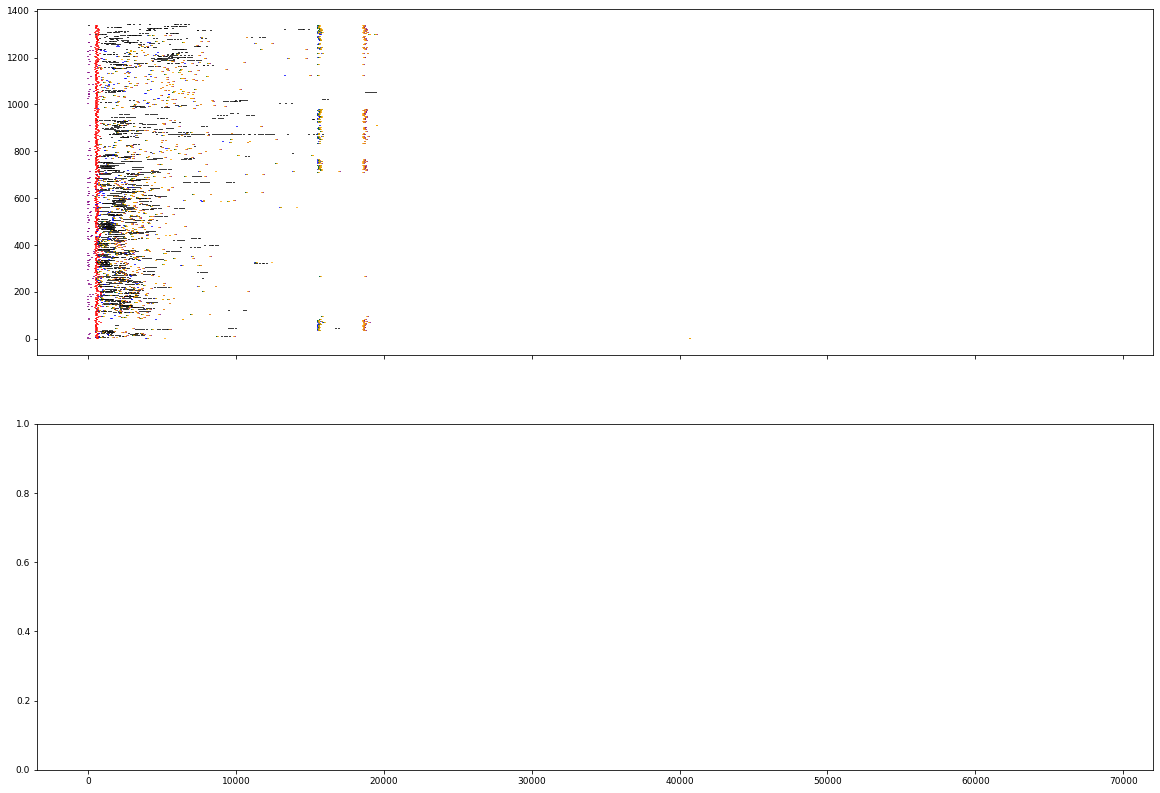

In [48]:
fig, ax = plt.subplots(2, 1, figsize=(20, 14), sharex=True)

for idx in tqdm(range(len(all_trials_parsed_licks)-1)):
    ax[0].vlines(all_trials_parsed_licks[idx], idx - 1, idx + 1, color="black", alpha=1)

    ax[0].vlines(time_data["stimulus_onset_ms"].iloc[idx], idx - 1, idx + 1, color="red", alpha=1)
    ax[0].vlines(time_data["response_onset_ms"].iloc[idx], idx - 1, idx + 1, color="blue", alpha=1)
    ax[0].vlines(time_data["reinforcement_onset_ms"].iloc[idx], idx - 1, idx + 1, color="green", alpha=1)
    ax[0].vlines(time_data["intertrial_onset_ms"].iloc[idx], idx - 1, idx + 1, color="orange", alpha=1)
    ax[0].vlines(time_data["next_fixation_onset_ms"].iloc[idx], idx - 1, idx + 1, color="purple", alpha=1)
    ax[0].vlines(
        time_data["intertrial_onset_ms"].iloc[idx] + aggregate_data["intertrial_duration"].iloc[idx] * 1e3, idx - 1, idx + 1, color="orange", alpha=1
    )

ax[0].vlines(0, 0, 0, color="red", alpha=1, label="stimulus onset")
ax[0].vlines(0, 0, 0, color="blue", alpha=1, label="response onset")
ax[0].vlines(0, 0, 0, color="green", alpha=1, label="reinforcement onset")
ax[0].vlines(0, 0, 0, color="orange", alpha=1, label="intertrial onset")
ax[0].vlines(0, 0, 0, color="purple", alpha=1, label="next fixation onset")
ax[0].vlines(0, 0, 0, color="black", alpha=1, label="licks")

convolved_licks = convolved_licks = np.convolve(np.nansum(lick_matrix, axis=0), np.ones(500) / 500, mode="same")
ax[1].plot(convolved_licks / np.max(convolved_licks))
ax[1].vlines(time_data["stimulus_onset_ms"].mean(), 0, 1, color="red", alpha=1)
ax[1].vlines(time_data["response_onset_ms"].mean(), 0, 1, color="blue", alpha=1)
ax[1].vlines(time_data["reinforcement_onset_ms"].mean(), 0, 1, color="green", alpha=1)
ax[1].vlines(time_data["intertrial_onset_ms"].mean(), 0, 1, color="orange", alpha=1)
ax[1].vlines(time_data["next_fixation_onset_ms"].mean(), 0, 1, color="purple", alpha=1)

ax[0].set_ylabel("Trial Index", fontsize=20)
ax[1].set_ylabel("Normalized Lick", fontsize=20)
ax[1].set_xlabel("Time - Aligned on fixation onset", fontsize=20)

ax[0].legend(loc="upper left", bbox_to_anchor=(1, 1), fontsize=16)

plt.suptitle("All Sessions all trials", fontsize=25)

plt.tight_layout()

plt.show()

 84%|████████▍ | 1340/1587 [00:15<00:02, 87.55it/s]


IndexError: single positional indexer is out-of-bounds

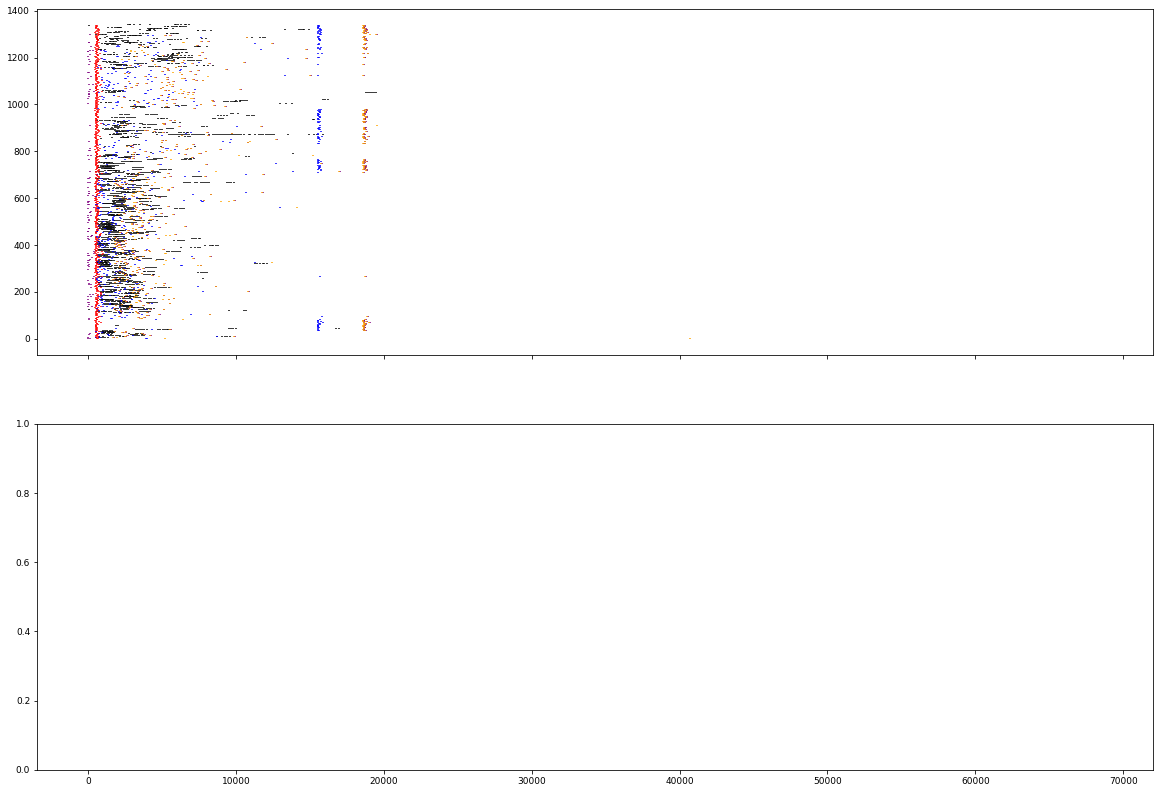

In [49]:
fig, ax = plt.subplots(2, 1, figsize=(20, 14), sharex=True)

for idx in tqdm(range(len(all_trials_parsed_licks)-1)):
    ax[0].vlines(all_trials_parsed_licks[idx], idx - 1, idx + 1, color="black", alpha=1)

    ax[0].vlines(time_data["stimulus_onset_ms"].iloc[idx], idx - 1, idx + 1, color="red", alpha=1)
    ax[0].vlines(time_data["response_onset_ms"].iloc[idx], idx - 1, idx + 1, color="blue", alpha=1)
    # ax[0].vlines(time_data["reinforcement_onset_ms"].iloc[idx], idx - 1, idx + 1, color="green", alpha=1)
    # ax[0].vlines(time_data["intertrial_onset_ms"].iloc[idx], idx - 1, idx + 1, color="orange", alpha=1)
    ax[0].vlines(time_data["next_fixation_onset_ms"].iloc[idx], idx - 1, idx + 1, color="purple", alpha=1)
    ax[0].vlines(
        time_data["intertrial_onset_ms"].iloc[idx] + aggregate_data["intertrial_duration"].iloc[idx] * 1e3, idx - 1, idx + 1, color="orange", alpha=1
    )

# ax[0].vlines(0, 0, 0, color="red", alpha=1, label="stimulus onset")
# ax[0].vlines(0, 0, 0, color="blue", alpha=1, label="response onset")
# # ax[0].vlines(0, 0, 0, color="green", alpha=1, label="reinforcement onset")
# # ax[0].vlines(0, 0, 0, color="orange", alpha=1, label="intertrial onset")
# ax[0].vlines(0, 0, 0, color="purple", alpha=1, label="next fixation onset")
# ax[0].vlines(0, 0, 0, color="black", alpha=1, label="licks")

# convolved_licks = convolved_licks = np.convolve(np.nansum(lick_matrix, axis=0), np.ones(500) / 500, mode="same")
# ax[1].plot(convolved_licks / np.max(convolved_licks))
cum_licks = np.cumsum(np.nansum(lick_matrix, axis=0))
ax[1].plot(cum_licks / max(cum_licks))
ax[1].vlines(time_data["stimulus_onset_ms"].mean(), 0, 1, color="red", alpha=1)
ax[1].vlines(time_data["response_onset_ms"].mean(), 0, 1, color="blue", alpha=1)
# ax[1].vlines(time_data["reinforcement_onset_ms"].mean(), 0, 1, color="green", alpha=1)
# ax[1].vlines(time_data["intertrial_onset_ms"].mean(), 0, 1, color="orange", alpha=1)
ax[1].vlines(time_data["next_fixation_onset_ms"].mean(), 0, 1, color="purple", alpha=1)

ax[0].set_ylabel("Trial Index", fontsize=20)
ax[1].set_ylabel("Cumulative Lick", fontsize=20)
ax[1].set_xlabel("Time - Aligned on fixation onset", fontsize=20)

ax[0].legend(loc="upper left", bbox_to_anchor=(1, 1), fontsize=16)

ax[0].set_xlim(0, 15000)
ax[1].set_xlim(0, 15000)

plt.suptitle("All Sessions all trials", fontsize=25)

plt.tight_layout()

plt.show()

## Reward aligned

In [131]:
correct_aggregate_data = aggregate_data[aggregate_data["outcome"] == 1]

unique_sessions = correct_aggregate_data[["mouse_id", "session_id"]].drop_duplicates()

# Initialize a larger array to store all trials with global indexing
max_licks_per_trial = 200  # Adjust based on the maximum licks per trial
correct_trials_parsed_licks = np.empty([len(correct_aggregate_data), max_licks_per_trial]) * np.NaN

global_trial_idx = 0  # Initialize a global trial index

for _, (mouse_id, session_id) in unique_sessions.iterrows():
    # Get the data for the current session
    trials = correct_aggregate_data[(correct_aggregate_data["mouse_id"] == mouse_id) & (correct_aggregate_data["session_id"] == session_id)]
    licks = aggregate_licks[(aggregate_licks["mouse_id"] == mouse_id) & (aggregate_licks["session_id"] == session_id)]

    start = trials["response_onset_ms"]
    end = trials["next_fixation_onset_ms"] + 1000

    for idx_trial in range(len(trials)):
        # Get the licks for the current trial
        parsed_trial_licks = licks['session_time'][(licks["session_time"] > start.iloc[idx_trial]) & (licks["session_time"] < end.iloc[idx_trial])].values.astype(int)

        correct_trials_parsed_licks[global_trial_idx, :len(parsed_trial_licks)] = parsed_trial_licks - start.iloc[idx_trial]

        global_trial_idx += 1

In [132]:
correct_time_data = correct_aggregate_data[
    [
        "fixation_onset_ms",
        "stimulus_onset_ms",
        "response_onset_ms",
        "reinforcement_onset_ms",
        "intertrial_onset_ms",
        "next_fixation_onset_ms",
    ]
]
correct_time_data = correct_time_data.subtract(correct_aggregate_data["response_onset_ms"], axis=0)
correct_time_data = pd.concat([correct_aggregate_data[["mouse_id", "session_id"]], correct_time_data], axis=1)

In [133]:
correct_aggregate_data.shape, correct_time_data.shape

((12636, 28), (12636, 8))

In [97]:
# Identify indices of trials to remove
trials_to_remove = np.where(correct_time_data["next_fixation_onset_ms"] < 0)[0]
# Get actual indices to remove from time_data
indices_to_remove = correct_time_data.index[trials_to_remove]
print(indices_to_remove.shape)

print(correct_time_data.shape)
correct_time_data = correct_time_data.drop(indices_to_remove, axis=0).reset_index(drop=True)
print(correct_time_data.shape)

(9809,)
(16778, 8)
(221, 8)


In [135]:
# Identify indices of trials to remove
trials_to_remove = np.where(time_data["next_fixation_onset_ms"].fillna(0) < 0)[0]

# Get actual indices to remove from time_data
indices_to_remove = correct_time_data.index[trials_to_remove]


# Drop rows from time_data and aggregate_data based on indices
correct_time_data = correct_time_data.drop(indices_to_remove, axis=0).reset_index(drop=True)
correct_aggregate_data = correct_aggregate_data.drop(indices_to_remove, axis=0).reset_index(drop=True)

# Remove trials from the numpy array
correct_trials_parsed_licks = np.delete(correct_trials_parsed_licks, trials_to_remove, axis=0)

In [137]:
max_trial_duration

431000

In [145]:
max_trial_duration = 100000#int(np.ceil(np.nanmax(correct_trials_parsed_licks) / 100))
correct_lick_matrix = np.zeros((len(correct_trials_parsed_licks), max_trial_duration))
# fill ones in lick_matrix where licks were detected
for trial_idx in range(len(correct_trials_parsed_licks)):
    correct_lick_matrix[trial_idx, correct_trials_parsed_licks[trial_idx][~np.isnan(correct_trials_parsed_licks[trial_idx])].astype(int)] = 1

IndexError: index 131913 is out of bounds for axis 1 with size 100000

In [ ]:
for idx in tqdm(range(len(correct_trials_parsed_licks))):
    # print(idx, end - start)
    # ax[0].vlines(correct_trials_parsed_licks[idx], idx - 1, idx + 1, color="black", alpha=1)
    correct_trials_parsed_licks[idx]
    

  0%|          | 11/6969 [00:00<01:03, 109.62it/s]C:\Users\mablab\AppData\Roaming\Python\Python38\site-packages\matplotlib\axes\_base.py:2503: UserWarning: Warning: converting a masked element to nan.
  xys = np.asarray(xys)
100%|██████████| 6969/6969 [00:56<00:00, 122.76it/s]


  0%|          | 23/12636 [00:00<02:44, 76.74it/s]C:\Users\mablab\AppData\Roaming\Python\Python38\site-packages\matplotlib\axes\_base.py:2503: UserWarning: Warning: converting a masked element to nan.
  xys = np.asarray(xys)
100%|██████████| 12636/12636 [02:23<00:00, 88.21it/s] 


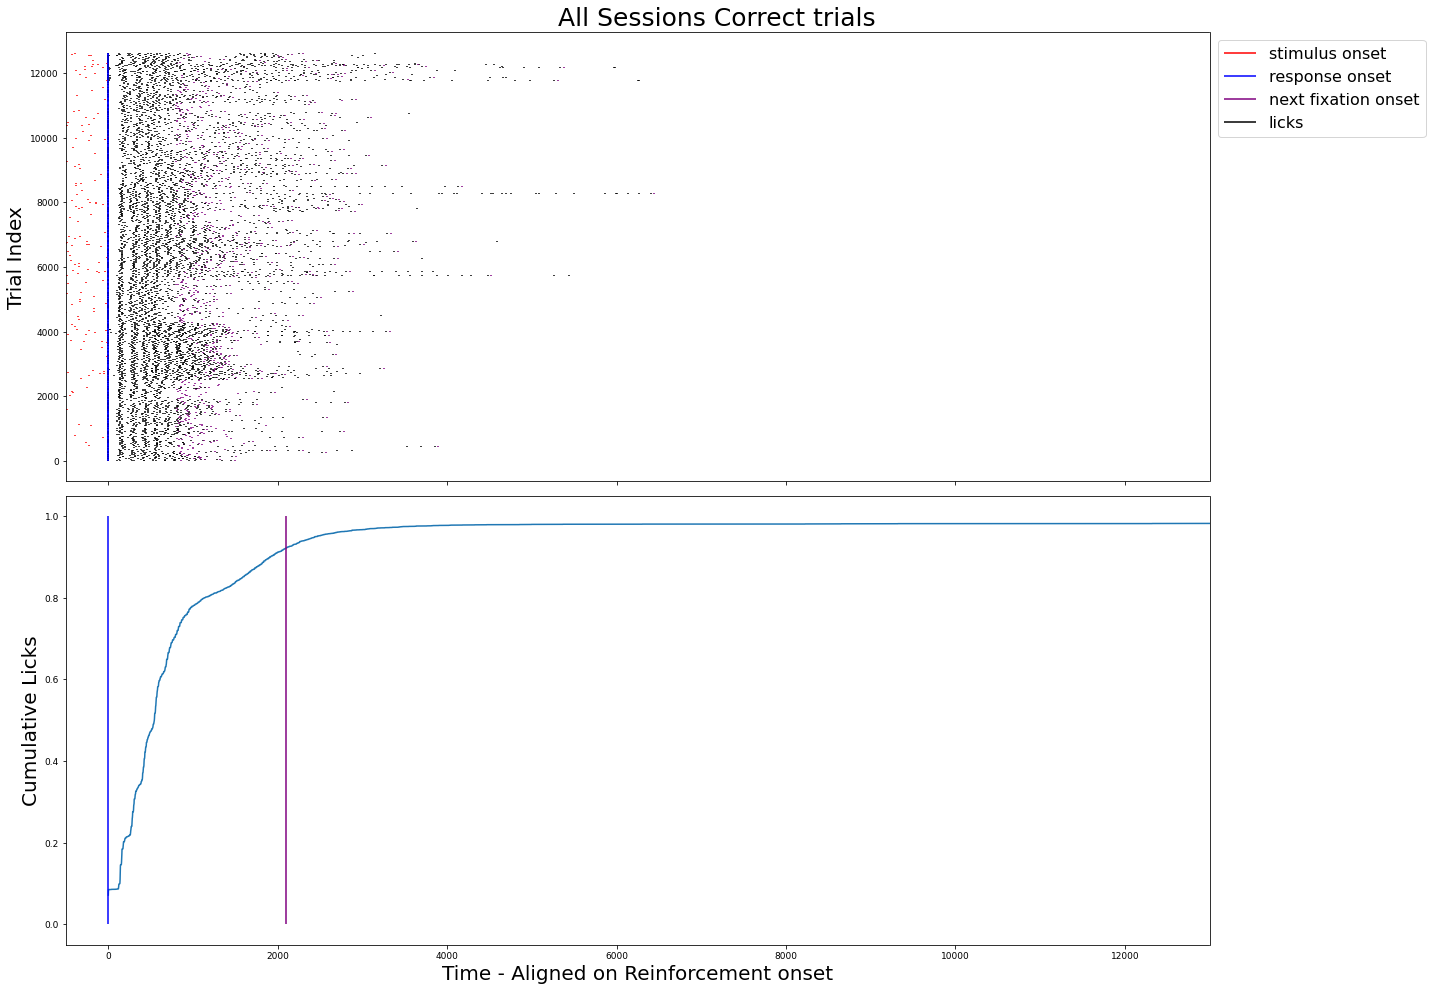

In [151]:
fig, ax = plt.subplots(2, 1, figsize=(20, 14), sharex=True)

for idx in tqdm(range(len(correct_trials_parsed_licks))):
    ax[0].vlines(correct_trials_parsed_licks[idx], idx - 1, idx + 1, color="black", alpha=1)

    ax[0].vlines(correct_time_data["stimulus_onset_ms"].iloc[idx], idx - 1, idx + 1, color="red", alpha=1)
    ax[0].vlines(correct_time_data["response_onset_ms"].iloc[idx], idx - 1, idx + 1, color="blue", alpha=1)
    # ax[0].vlines(correct_time_data["reinforcement_onset_ms"].iloc[idx], idx - 1, idx + 1, color="green", alpha=1)
    # ax[0].vlines(correct_time_data["intertrial_onset_ms"].iloc[idx], idx - 1, idx + 1, color="orange", alpha=1)
    ax[0].vlines(correct_time_data["next_fixation_onset_ms"].iloc[idx], idx - 1, idx + 1, color="purple", alpha=1)


ax[0].vlines(0, 0, 0, color="red", alpha=1, label="stimulus onset")
ax[0].vlines(0, 0, 0, color="blue", alpha=1, label="response onset")
# ax[0].vlines(0, 0, 0, color="green", alpha=1, label="reinforcement onset")
# ax[0].vlines(0, 0, 0, color="orange", alpha=1, label="intertrial onset")
ax[0].vlines(0, 0, 0, color="purple", alpha=1, label="next fixation onset")
ax[0].vlines(0, 0, 0, color="black", alpha=1, label="licks")

# convolved_licks = np.convolve(np.nansum(correct_lick_matrix, axis=0), np.ones(500) / 500, mode="same")
# ax[1].plot(convolved_licks / np.max(convolved_licks))
cum_licks = np.cumsum(np.mean(correct_lick_matrix, axis=0))
plt.plot(cum_licks / max(cum_licks))
ax[1].vlines(correct_time_data["stimulus_onset_ms"].mean(), 0, 1, color="red", alpha=1)
ax[1].vlines(correct_time_data["response_onset_ms"].mean(), 0, 1, color="blue", alpha=1)
# ax[1].vlines(correct_time_data["reinforcement_onset_ms"].mean(), 0, 1, color="green", alpha=1)
# ax[1].vlines(correct_time_data["intertrial_onset_ms"].mean(), 0, 1, color="orange", alpha=1)
ax[1].vlines(correct_time_data["next_fixation_onset_ms"].mean(), 0, 1, color="purple", alpha=1)

ax[0].set_ylabel("Trial Index", fontsize=20)
ax[1].set_ylabel("Cumulative Licks", fontsize=20)
ax[1].set_xlabel("Time - Aligned on Reinforcement onset", fontsize=20)

ax[0].legend(loc="upper left", bbox_to_anchor=(1, 1), fontsize=16)

ax[0].set_xlim(-500, 13000)
ax[1].set_xlim(-500, 13000)

plt.suptitle("All Sessions Correct trials", fontsize=25)

plt.tight_layout()

plt.show()

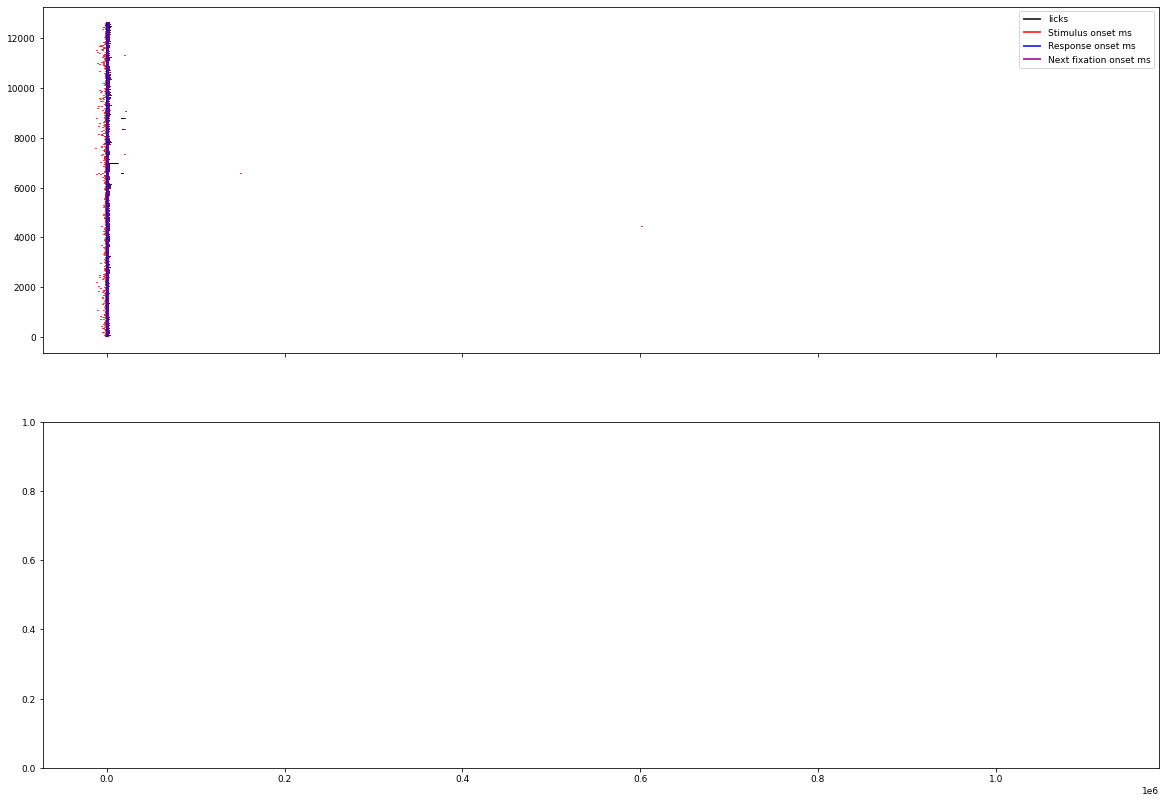

In [150]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(2, 1, figsize=(20, 14), sharex=True)

# Generate Y values (trial indices)
y_vals = np.arange(len(correct_time_data))

# --- Fix the licks parsing issue ---
# Flatten the nested list of licks safely (some lists might be empty)
licks_x = np.hstack(correct_trials_parsed_licks)  # Flatten without shape issues
licks_y = np.repeat(y_vals, [len(trial) for trial in correct_trials_parsed_licks])  # Repeat Y values correctly

# Plot all "licks" events at once
ax[0].vlines(licks_x, licks_y - 1, licks_y + 1, color="black", alpha=1, label="licks")

# Plot other event types at once
event_colors = {"stimulus_onset_ms": "red", "response_onset_ms": "blue", "next_fixation_onset_ms": "purple"}

for event, color in event_colors.items():
    ax[0].vlines(
        correct_time_data[event].values,  # Use `.values` to avoid indexing overhead
        y_vals - 1,
        y_vals + 1,
        color=color,
        alpha=1,
        label=event.replace("_", " ").capitalize(),
    )

# Add legend
ax[0].legend()

plt.show()

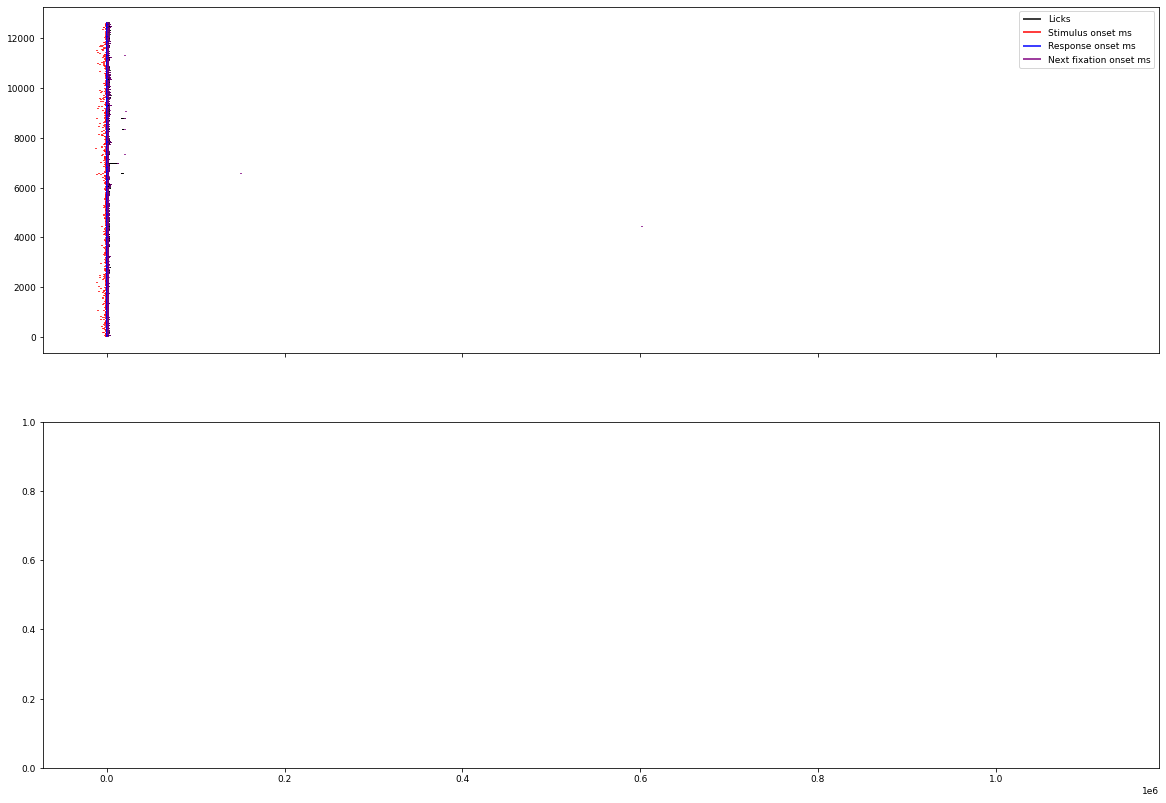

In [152]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection

# Create figure
fig, ax = plt.subplots(2, 1, figsize=(20, 14), sharex=True)

# Generate Y values (trial indices)
y_vals = np.arange(len(correct_time_data))


# Function to create vertical lines efficiently
def create_vlines(x_values, y_values, color, label):
    """
    Create vertical lines using LineCollection for better performance.
    """
    segments = [((x, y - 1), (x, y + 1)) for x, y in zip(x_values, y_values)]
    line_collection = LineCollection(segments, colors=color, alpha=1, label=label)
    ax[0].add_collection(line_collection)


# --- Plot "licks" efficiently ---
# Flatten correct_trials_parsed_licks properly
licks_x = np.hstack(correct_trials_parsed_licks)  # Flatten
licks_y = np.repeat(y_vals, [len(trial) for trial in correct_trials_parsed_licks])  # Ensure correct y-values

# Add licks using LineCollection
create_vlines(licks_x, licks_y, "black", "Licks")

# --- Plot event times in bulk ---
event_colors = {"stimulus_onset_ms": "red", "response_onset_ms": "blue", "next_fixation_onset_ms": "purple"}

for event, color in event_colors.items():
    create_vlines(correct_time_data[event].values, y_vals, color, event.replace("_", " ").capitalize())

# Legend
ax[0].legend()
ax[0].autoscale()  # Scale the plot properly
plt.show()